In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
routes_df = pd.read_csv("../data/routes_data.csv")
delay_df = pd.read_csv(
    "../data/delay_data.csv",
    low_memory=False
)
booking_df = pd.read_csv(
    "../data/booking_data.csv",
    encoding="latin1"
)

In [ ]:
routes_df.head()



,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [11]:
routes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

In [ ]:
booking_df.head()

FL_DATE                          0
AIRLINE                          0
AIRLINE_DOT                      0
AIRLINE_CODE                     0
DOT_CODE                         0
FL_NUMBER                        0
ORIGIN                           0
ORIGIN_CITY                      0
DEST                             0
DEST_CITY                        0
CRS_DEP_TIME                     0
DEP_TIME                     77615
DEP_DELAY                    77644
TAXI_OUT                     78806
WHEELS_OFF                   78806
WHEELS_ON                    79944
TAXI_IN                      79944
CRS_ARR_TIME                     0
ARR_TIME                     79942
ARR_DELAY                    86198
CANCELLED                        0
CANCELLATION_CODE          2920860
DIVERTED                         0
CRS_ELAPSED_TIME                14
ELAPSED_TIME                 86198
AIR_TIME                     86198
DISTANCE                         0
DELAY_DUE_CARRIER          2466137
DELAY_DUE_WEATHER   

In [14]:
delay_df.info()
delay_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245955 entries, 0 to 245954
Data columns (total 23 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tbl             245955 non-null  object 
 1   Year            245955 non-null  int64  
 2   quarter         245955 non-null  int64  
 3   citymarketid_1  245955 non-null  int64  
 4   citymarketid_2  245955 non-null  int64  
 5   city1           245955 non-null  object 
 6   city2           245955 non-null  object 
 7   airportid_1     245955 non-null  int64  
 8   airportid_2     245955 non-null  int64  
 9   airport_1       245955 non-null  object 
 10  airport_2       245955 non-null  object 
 11  nsmiles         245955 non-null  int64  
 12  passengers      245955 non-null  int64  
 13  fare            245955 non-null  float64
 14  carrier_lg      244415 non-null  object 
 15  large_ms        244415 non-null  float64
 16  fare_lg         244415 non-null  float64
 17  carrier_lo

tbl                   0
Year                  0
quarter               0
citymarketid_1        0
citymarketid_2        0
city1                 0
city2                 0
airportid_1           0
airportid_2           0
airport_1             0
airport_2             0
nsmiles               0
passengers            0
fare                  0
carrier_lg         1540
large_ms           1540
fare_lg            1540
carrier_low        1612
lf_ms              1612
fare_low           1612
Geocoded_City1    39206
Geocoded_City2    39206
tbl1apk               0
dtype: int64

In [15]:
booking_df.info()
booking_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

In [16]:
print(routes_df.shape)
print(delay_df.shape)
print(booking_df.shape)
print(routes_df.columns.tolist())
print(delay_df.columns.tolist())
print(booking_df.columns.tolist())

(3000000, 32)
(245955, 23)
(50000, 14)
['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE', 'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']
['tbl', 'Year', 'quarter', 'citymarketid_1', 'citymarketid_2', 'city1', 'city2', 'airportid_1', 'airportid_2', 'airport_1', 'airport_2', 'nsmiles', 'passengers', 'fare', 'carrier_lg', 'large_ms', 'fare_lg', 'carrier_low', 'lf_ms', 'fare_low', 'Geocoded_City1', 'Geocoded_City2', 'tbl1apk']
['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead', 'length_of_stay', 'flight_hour', 'flight_day', 'route', 'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_fli

In [17]:
delay_df["route"] = (
    delay_df["city1"]
    + " → " +
    delay_df["city2"]
)

main_df = delay_df[
    [
        "Year",
        "quarter",
        "route",
        "city1",
        "city2",
        "nsmiles",
        "passengers",
        "fare"
    ]
]

main_df = main_df.rename(
    columns={
        "quarter": "Quarter",
        "nsmiles": "Distance",
        "passengers": "Passengers",
        "fare": "Fare"
    }
)

main_df.head()

,Year,Quarter,route,city1,city2,Distance,Passengers,Fare
0,2021,3,"Allentown/Bethlehem/Easton, PA → Tampa, FL (Me...","Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",970,180,81.43
1,2021,3,"Allentown/Bethlehem/Easton, PA → Tampa, FL (Me...","Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",970,19,208.93
2,2021,3,"Albuquerque, NM → Dallas/Fort Worth, TX","Albuquerque, NM","Dallas/Fort Worth, TX",580,204,184.56
3,2021,3,"Albuquerque, NM → Dallas/Fort Worth, TX","Albuquerque, NM","Dallas/Fort Worth, TX",580,264,182.64
4,2021,3,"Albuquerque, NM → Phoenix, AZ","Albuquerque, NM","Phoenix, AZ",328,398,177.11


In [18]:
main_df.isnull().sum()

Year          0
Quarter       0
route         0
city1         0
city2         0
Distance      0
Passengers    0
Fare          0
dtype: int64

In [19]:
top_routes = (
    main_df.groupby("route")
    ["Passengers"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(top_routes)

route
Denver, CO → Phoenix, AZ                                           2615.857143
Phoenix, AZ → Seattle, WA                                          2217.231884
Las Vegas, NV → San Diego, CA                                      2103.666667
Las Vegas, NV → Seattle, WA                                        1974.400000
Denver, CO → Las Vegas, NV                                         1955.666667
San Diego, CA → San Francisco, CA (Metropolitan Area)              1843.031073
San Francisco, CA (Metropolitan Area) → Seattle, WA                1693.053521
Las Vegas, NV → San Francisco, CA (Metropolitan Area)              1684.650704
Minneapolis/St. Paul, MN → Phoenix, AZ                             1651.658228
Atlanta, GA (Metropolitan Area) → Miami, FL (Metropolitan Area)    1627.283898
Name: Passengers, dtype: float64


In [20]:
top_fares = (
    main_df.groupby("route")
    ["Fare"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(top_fares)

route
Eagle, CO → Miami, FL (Metropolitan Area)                   430.639667
Jackson, WY → New York City, NY (Metropolitan Area)         425.305878
Aspen, CO → New York City, NY (Metropolitan Area)           418.618156
Aspen, CO → Miami, FL (Metropolitan Area)                   398.735000
El Paso, TX → Miami, FL (Metropolitan Area)                 391.130000
Huntsville, AL → Los Angeles, CA (Metropolitan Area)        372.231333
Bozeman, MT → New York City, NY (Metropolitan Area)         365.010625
Eagle, CO → New York City, NY (Metropolitan Area)           364.070526
New York City, NY (Metropolitan Area) → Palm Springs, CA    355.134983
Chicago, IL → Key West, FL                                  349.176250
Name: Fare, dtype: float64


In [21]:
quarter_demand = (
    main_df.groupby("Quarter")
    ["Passengers"]
    .mean()
)

print(quarter_demand)


Quarter
1    278.260776
2    313.430010
3    300.251879
4    307.154820
Name: Passengers, dtype: float64


In [22]:
from sklearn.preprocessing import LabelEncoder

route_encoder = LabelEncoder()

main_df["route_encoded"] = route_encoder.fit_transform(
    main_df["route"]
)

main_df.head()

,Year,Quarter,route,city1,city2,Distance,Passengers,Fare,route_encoded
0,2021,3,"Allentown/Bethlehem/Easton, PA → Tampa, FL (Me...","Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",970,180,81.43,30
1,2021,3,"Allentown/Bethlehem/Easton, PA → Tampa, FL (Me...","Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",970,19,208.93,30
2,2021,3,"Albuquerque, NM → Dallas/Fort Worth, TX","Albuquerque, NM","Dallas/Fort Worth, TX",580,204,184.56,13
3,2021,3,"Albuquerque, NM → Dallas/Fort Worth, TX","Albuquerque, NM","Dallas/Fort Worth, TX",580,264,182.64,13
4,2021,3,"Albuquerque, NM → Phoenix, AZ","Albuquerque, NM","Phoenix, AZ",328,398,177.11,22


In [23]:
X = main_df[
    [
        "Year",
        "Quarter",
        "Distance",
        "Fare",
        "route_encoded"
    ]
]

y = main_df["Passengers"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

In [26]:
predictions = model.predict(X_test)

In [27]:
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 190.61813405520368
R2 Score: 0.41118935012926416


In [28]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_split=5, n_estimators=200,
                      n_jobs=-1, random_state=42)

In [29]:
predictions = model.predict(X_test)

In [30]:
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 202.32735270344665
R2 Score: 0.4398423211693211


In [31]:
def get_season(q):
    if q == 1:
        return 1
    
    elif q == 2:
        return 2
    
    elif q == 3:
        return 3
    
    else:
        return 4


main_df["Season"] = (
    main_df["Quarter"]
    .apply(get_season)
)

In [32]:
route_avg = (
    main_df.groupby("route")
    ["Passengers"]
    .mean()
)

main_df["route_popularity"] = (
    main_df["route"]
    .map(route_avg)
)

In [33]:
X = main_df[
    [
        "Year",
        "Quarter",
        "Season",
        "Distance",
        "Fare",
        "route_encoded",
        "route_popularity"
    ]
]

y = main_df["Passengers"]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [36]:
predictions = model.predict(X_test)

In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 187.01826039848558
R2 Score: 0.424113538220103


In [38]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [39]:
X = main_df[
    [
        "Year",
        "Quarter",
        "Distance",
        "Fare",
        "route"
    ]
]

y = main_df["Passengers"]

In [40]:
categorical_features = ["route"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [41]:
X_processed = preprocessor.fit_transform(X)

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [44]:
predictions = model.predict(X_test)

In [45]:
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 186.06218050800038
R2 Score: 0.40800140611519087


In [46]:
def recommend_flights(
    predicted_passengers,
    aircraft_capacity=180,
    occupancy_target=0.85
):
    
    seats_needed = (
        predicted_passengers /
        occupancy_target
    )

    flights_needed = (
        seats_needed /
        aircraft_capacity
    )

    return round(flights_needed)

In [47]:
sample_prediction = 720

recommended = recommend_flights(
    sample_prediction
)

print(
    "Recommended Flights/Day:",
    recommended
)

Recommended Flights/Day: 5


In [48]:
sample_input = pd.DataFrame({
    "Year": [2024],
    "Quarter": [2],
    "Distance": [800],
    "Fare": [180],
    "route": ["Dallas/Fort Worth, TX → Phoenix, AZ"]
})

In [49]:
sample_input_processed = preprocessor.transform(
    sample_input
)

In [50]:
predicted_passengers = model.predict(
    sample_input_processed
)

print(
    "Predicted Passengers:",
    predicted_passengers[0]
)

Predicted Passengers: 628.595


In [51]:
recommended_flights = recommend_flights(
    predicted_passengers[0]
)

print(
    "Recommended Flights/Day:",
    recommended_flights
)

Recommended Flights/Day: 4


#ROUTES

In [52]:
routes_df["departure_hour"] = (
    routes_df["CRS_DEP_TIME"] // 100
)

In [53]:
delay_by_hour = (
    routes_df.groupby("departure_hour")
    ["DEP_DELAY"]
    .mean()
)

print(delay_by_hour)

departure_hour
0     11.126733
1     12.435042
2     21.388732
3     12.167323
4     13.541401
5      3.816252
6      3.598104
7      3.972860
8      4.697195
9      5.568547
10     6.800312
11     7.542396
12     8.949635
13    10.284115
14    11.608259
15    12.524197
16    13.712098
17    14.405064
18    15.576716
19    16.977895
20    16.617609
21    17.108229
22    16.606416
23    14.738788
Name: DEP_DELAY, dtype: float64


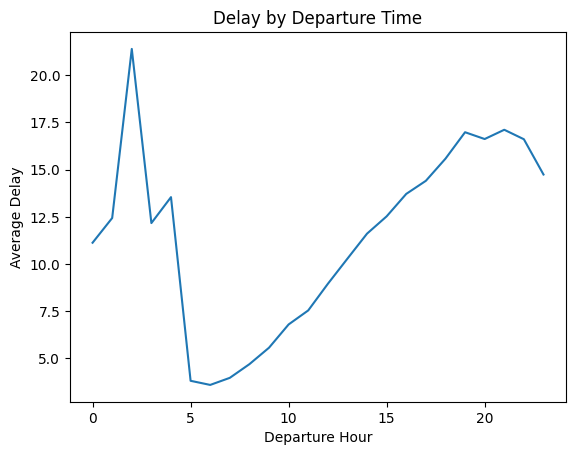

In [54]:
import matplotlib.pyplot as plt

delay_by_hour.plot()

plt.xlabel("Departure Hour")
plt.ylabel("Average Delay")
plt.title("Delay by Departure Time")

plt.show()

In [56]:
import joblib

joblib.dump(
    model,
    "../models/demand_model.pkl"
)

joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

print("Model Saved!")

Model Saved!


In [57]:
import joblib

all_routes = (
    main_df["route"]
    .unique()
    .tolist()
)

joblib.dump(
    all_routes,
    "../models/routes.pkl"
)

print("Routes Saved!")

Routes Saved!
